# Taller Final Integrador — Clustering aplicado a escenarios reales

**Dataset seleccionado:** Iris  
**Tipo de problema:** Aprendizaje no supervisado mediante clustering  
**Algoritmos comparados:** K-Means y Mean Shift

> Nota: la columna `especie_real` se conserva solamente como referencia de validación externa. Los algoritmos no la usan para entrenar.


## 1. Información del equipo

Integrantes del grupo:
1.   Ainoa Bolea Villa
2.   Santiago Gonzalez Garzon
3.   Mateo Giraldo Soto
4.   Juan Jose Velez Mejia

Dataset o imagen seleccionada: Dataset Iris.  
Tipo de problema: Clustering / aprendizaje no supervisado.  
Contexto real: agrupación automática de flores a partir de mediciones morfológicas.

## 2. Entendimiento del problema

El clustering consiste en agrupar observaciones similares entre sí sin utilizar etiquetas previamente conocidas. En este caso se busca descubrir si las flores pueden agruparse naturalmente a partir de sus características físicas.

Este problema puede resolverse con aprendizaje no supervisado porque el algoritmo no necesita conocer la especie real de la flor. Solo analiza las distancias entre observaciones y forma grupos según similitud.

Encontrar estos grupos tiene valor porque permite descubrir estructuras ocultas. En un entorno profesional, la misma lógica puede aplicarse a segmentación de clientes, agrupación de productos, detección de perfiles de comportamiento o análisis de imágenes.

## 3. Importar librerías

Se cargan librerías para manipulación de datos, visualización, escalamiento, clustering, evaluación y reducción de dimensión.

In [ ]:
# Librerías para manejo de datos
import numpy as np
import pandas as pd

# Librería para visualización
import matplotlib.pyplot as plt

# Dataset y herramientas de aprendizaje automático
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

### Interpretación

Estas librerías permiten cubrir todo el flujo del taller: cargar datos, explorarlos, prepararlos, aplicar K-Means y Mean Shift, evaluar la calidad de los clusters y visualizar resultados en dos dimensiones.

## 4. Carga de datos

Se carga el dataset Iris y se organiza en un DataFrame para facilitar su análisis.

In [ ]:
# Cargar dataset Iris desde scikit-learn
iris = load_iris()

# Crear DataFrame con nombres de variables en español
df = pd.DataFrame(
    iris.data,
    columns=[
        "longitud_sepalo_cm",
        "ancho_sepalo_cm",
        "longitud_petalo_cm",
        "ancho_petalo_cm"
    ]
)

# Agregar especie real solo para referencia externa, no para entrenar clustering
df["especie_real"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Mostrar primeras filas
df.head()

,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm,especie_real
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Interpretación

El dataset contiene 150 flores y cuatro variables numéricas medidas en centímetros. La etiqueta real se conserva para comparar después, pero no se usa como entrada de los algoritmos de clustering.

## 5. Exploración inicial

Se revisan dimensiones, tipos de datos, estadísticos descriptivos y valores faltantes.

In [ ]:
# Revisar tamaño del dataset
print("Filas y columnas:", df.shape)

# Revisar tipos de datos y valores no nulos
print(df.info())

# Estadísticos descriptivos de variables numéricas
display(df.describe())

# Valores faltantes por columna
display(df.isnull().sum())

Filas y columnas: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitud_sepalo_cm  150 non-null    float64 
 1   ancho_sepalo_cm     150 non-null    float64 
 2   longitud_petalo_cm  150 non-null    float64 
 3   ancho_petalo_cm     150 non-null    float64 
 4   especie_real        150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None


,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


,0
longitud_sepalo_cm,0
ancho_sepalo_cm,0
longitud_petalo_cm,0
ancho_petalo_cm,0
especie_real,0


### Interpretación

No hay valores faltantes y las variables principales son numéricas. Aunque todas están en centímetros, sus rangos son diferentes; por eso es necesario escalar antes de aplicar algoritmos basados en distancia.

## 6. Preparación de los datos

Se seleccionan las variables numéricas y se escalan para que todas aporten de manera equilibrada al cálculo de distancias.

In [ ]:
# Seleccionar solo variables numéricas para clustering
X = df[[
    "longitud_sepalo_cm",
    "ancho_sepalo_cm",
    "longitud_petalo_cm",
    "ancho_petalo_cm"
]]

# Escalar variables para evitar que una domine por su magnitud
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para visualizar resultado escalado
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### Interpretación

Se eligieron las cuatro variables morfológicas porque describen directamente la estructura de cada flor. El escalamiento es adecuado porque K-Means y Mean Shift calculan similitud mediante distancias.

## 7. Aplicación de K-Means

Se aplica K-Means con 3 clusters, una elección coherente con el caso Iris y posteriormente respaldada por el método del codo.

In [ ]:
# Crear modelo K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Entrenar modelo y obtener etiquetas de cluster
labels_kmeans = kmeans.fit_predict(X_scaled)

# Guardar resultados en el DataFrame
df["cluster_kmeans"] = labels_kmeans

# Ver cantidad de observaciones por cluster
df["cluster_kmeans"].value_counts().sort_index()

,count
cluster_kmeans,
0,53
1,50
2,47


### Interpretación

K-Means asignó cada flor a uno de tres grupos. Uno de los clusters suele quedar claramente separado, mientras los otros dos pueden estar más cercanos porque algunas especies del dataset tienen características similares.

## 8. Método del codo

Se evalúan distintos valores de K para observar cómo cambia la inercia.

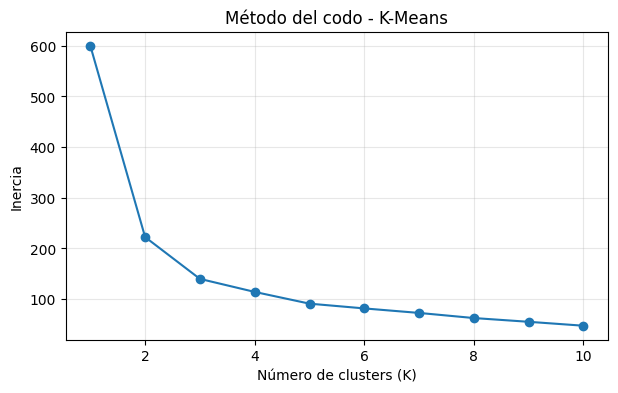

In [ ]:
# Lista para guardar inercia
inertia = []

# Probar K desde 1 hasta 10
K = range(1, 11)

for k in K:
    # Crear y entrenar modelo para cada K
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)

    # Guardar inercia
    inertia.append(model.inertia_)

# Graficar método del codo
plt.figure(figsize=(7, 4))
plt.plot(K, inertia, marker="o")
plt.title("Método del codo - K-Means")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

La curva baja rápidamente hasta aproximadamente K=3. Después de ese punto sigue disminuyendo, pero con menor ganancia. Por eso K=3 es una elección razonable e interpretable.

## 9. Silhouette Score

Se calcula silhouette para medir qué tan bien separado y cohesionado está el agrupamiento.

In [ ]:
# Calcular silhouette para K-Means con K=3
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print("Silhouette K-Means:", score_kmeans)

# Comparar silhouette para varios K
silhouette_values = {}

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    silhouette_values[k] = silhouette_score(X_scaled, labels)

pd.DataFrame({
    "K": list(silhouette_values.keys()),
    "Silhouette": list(silhouette_values.values())
})

Silhouette K-Means: 0.45994823920518635


,K,Silhouette
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079
5,7,0.320197
6,8,0.338692
7,9,0.342360
8,10,0.351793


### Interpretación

El silhouette de K-Means con K=3 es cercano a 0.46. Esto indica una separación moderada: los clusters tienen sentido, pero no están perfectamente aislados. La métrica complementa el método del codo porque no solo mira compactación interna, sino también separación entre grupos.

## 10. Visualización de clusters K-Means

Se usa PCA para proyectar las cuatro variables en dos dimensiones y poder visualizar los clusters.

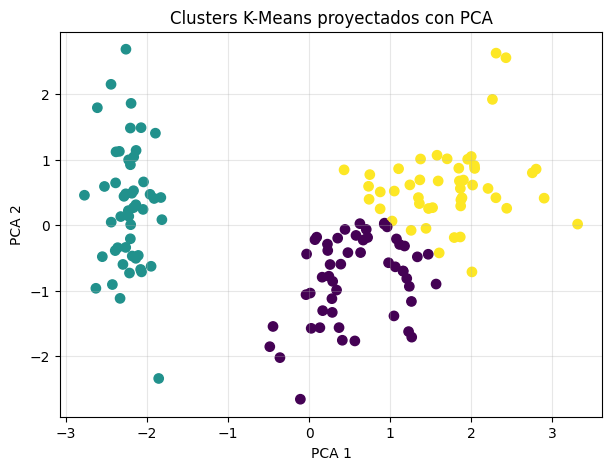

In [ ]:
# Reducir a dos dimensiones solo para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Graficar clusters
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, s=45)
plt.title("Clusters K-Means proyectados con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

La gráfica muestra un grupo claramente separado y dos grupos más cercanos. Esto refleja que algunas flores se distinguen muy bien por sus pétalos, mientras otras comparten características más parecidas.

## 11. Aplicación de Mean Shift

Se aplica Mean Shift estimando automáticamente el ancho de banda.

In [ ]:
# Estimar ancho de banda para Mean Shift
bandwidth = estimate_bandwidth(X_scaled, quantile=0.25, n_samples=len(X_scaled), random_state=42)

# Crear y entrenar modelo Mean Shift
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = meanshift.fit_predict(X_scaled)

# Guardar etiquetas en el DataFrame
df["cluster_meanshift"] = labels_ms

# Número de clusters encontrados
n_clusters_ms = len(np.unique(labels_ms))

print("Bandwidth:", bandwidth)
print("Clusters encontrados por Mean Shift:", n_clusters_ms)
df["cluster_meanshift"].value_counts().sort_index()

Bandwidth: 1.3894408815534491
Clusters encontrados por Mean Shift: 3


,count
cluster_meanshift,
0,94
1,50
2,6


### Interpretación

Mean Shift no recibió el número de clusters previamente; lo calculó a partir de zonas densas. En este caso encontró 3 clusters. Su resultado depende fuertemente del ancho de banda elegido.

## 12. Visualización de Mean Shift

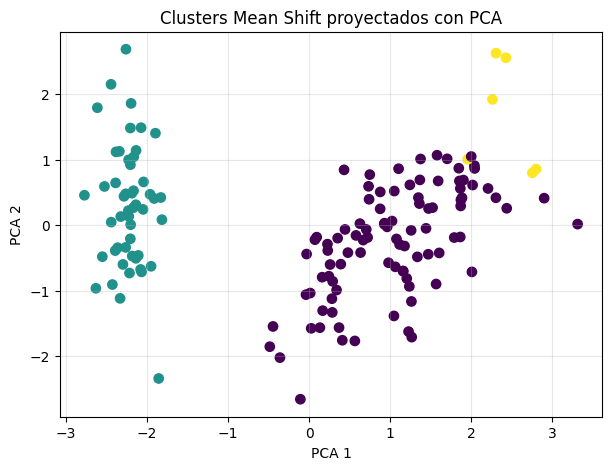

In [ ]:
# Visualizar clusters de Mean Shift en espacio PCA
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ms, s=45)
plt.title("Clusters Mean Shift proyectados con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

Mean Shift también identifica una estructura de tres grupos. Sin embargo, puede ser menos estable que K-Means si el parámetro bandwidth no se ajusta correctamente.

## 13. Caso especial: imágenes

No aplica para este taller porque se trabajó con un dataset tabular. Si se trabajara con imágenes, cada píxel podría representarse como un vector RGB o HSV para segmentar colores o regiones. HSV suele ser útil cuando interesa separar por tono y saturación, mientras RGB trabaja directamente con intensidades de color.

## 14. Comparación final entre algoritmos

In [ ]:
# Métricas de comparación
sil_ms = silhouette_score(X_scaled, labels_ms)
ari_kmeans = adjusted_rand_score(iris.target, labels_kmeans)
ari_ms = adjusted_rand_score(iris.target, labels_ms)

comparacion = pd.DataFrame({
    "Algoritmo": ["K-Means", "Mean Shift"],
    "N_clusters": [3, n_clusters_ms],
    "Silhouette": [score_kmeans, sil_ms],
    "ARI_externo": [ari_kmeans, ari_ms]
})

comparacion

,Algoritmo,N_clusters,Silhouette,ARI_externo
0,K-Means,3,0.459948,0.620135
1,Mean Shift,3,0.437951,0.559650


### Interpretación

K-Means funcionó ligeramente mejor en este caso porque obtuvo mejor silhouette y mejor ARI externo. Además, es más simple, rápido e interpretable. Mean Shift tiene la ventaja de no exigir K previamente, pero es sensible al ancho de banda.

## 15. Aplicación real o propuesta de producción

Este flujo puede usarse para segmentar clientes, productos o registros biológicos. En producción se necesitaría una fuente de datos confiable, limpieza automatizada, validación con expertos, monitoreo de la calidad de clusters y reentrenamiento periódico.

## 16. Conclusiones

- El clustering permite descubrir estructuras ocultas sin etiquetas previas.
- El escalamiento fue fundamental porque los algoritmos usan distancias.
- K-Means fue el algoritmo más útil para este caso por su claridad e interpretación.
- Mean Shift es valioso porque estima grupos por densidad, pero depende mucho del bandwidth.
- Como mejora futura se podrían probar DBSCAN, Gaussian Mixture Models, t-SNE o UMAP para exploración visual.

## 17. Preguntas de cierre

1. **¿Qué limitaciones tiene K-Means?**  
   Requiere definir K, es sensible a la escala y a valores atípicos, y funciona mejor con clusters compactos.

2. **¿Qué ventajas tiene Mean Shift?**  
   No exige definir el número de clusters y encuentra grupos desde zonas densas.

3. **¿Por qué el espacio de representación importa en clustering?**  
   Porque la distancia depende de las variables usadas y de su escala. Una mala representación produce agrupamientos poco útiles.

4. **¿Qué harías diferente si tuvieras más tiempo o más datos?**  
   Probaría más algoritmos, evaluaría estabilidad, incluiría nuevas variables y validaría los clusters con expertos del dominio.
